This is the simulation code for a bike sharing system. A bike sharing system, which makes bikes available for shared use on a short-term basis, consists of a set of bikes a set of stations – equipped with docks – which spread over an area (e.g., a city). Each arriving user can take a bike from one station, ride a short journey within the area, and return the bike to any station in the network (either the same or another station).

There are three events in this model. Arrival event refers to the event of a new rider arriving at a station to rent a bike. Departure event refers to the event of a rider arriving at a station to return a bike. One key difference between these two events is that upon arrival event, if no bike is available in the station, the demand is missed, whereas in case of a departure event, if no idle dock is available in the station, the rider has to choose another station for returning the bike. Finally, midnight event refers to the event when the optimization model decides the optimal allocations to each station. Following this decision, the repositioning of the bikes will take place according to the optimization model if specified.


**Author: Ehsan Kehtari**

**Date: 4/10/2025**



In [ ]:
#!pip install gurobipy
import numpy as np
import random
import math
from gurobipy import Model, GRB
from scipy.stats import binom
import matplotlib as mpl
from matplotlib import pyplot as plt

In [ ]:
inputs = dict()

# Capacity of stations
inputs['Capacity'] = dict()
inputs['Capacity']['Station 1'] = 18
inputs['Capacity']['Station 2'] = 15
inputs['Capacity']['Station 3'] = 7
inputs['Capacity']['Station 4'] = 7
inputs['Capacity']['Station 5'] = 6
num_stations = len(inputs['Capacity'])

# Starting state
inputs['Start'] = dict()
inputs['Start']['Station 1'] = 15
inputs['Start']['Station 2'] = 15
inputs['Start']['Station 3'] = 5
inputs['Start']['Station 4'] = 5
inputs['Start']['Station 5'] = 6
num_bikes = sum(inputs['Start'].values())

# Arrival rate ~ Exponential (minutes per arrival)
inputs['Arrival Rate'] = dict()
inputs['Arrival Rate']['Station 1'] = {
    '0-6': 120.,
    '6-8': 60.,
    '8-10': 15.,
    '10-12': 10.,
    '12-14': 20.,
    '14-16': 20.,
    '16-18': 15.,
    '18-20': 10.,
    '20-22': 60.,
    '22-24': 120.,
}
inputs['Arrival Rate']['Station 2'] = {
    '0-6': 120.,
    '6-8': 60.,
    '8-10': 15.,
    '10-12': 10.,
    '12-14': 20.,
    '14-16': 20.,
    '16-18': 15.,
    '18-20': 10.,
    '20-22': 60.,
    '22-24': 120.,
}
inputs['Arrival Rate']['Station 3'] = {
    '0-6': 120.,
    '6-8': 60.,
    '8-10': 15.,
    '10-12': 10.,
    '12-14': 20.,
    '14-16': 20.,
    '16-18': 15.,
    '18-20': 10.,
    '20-22': 60.,
    '22-24': 120.,
}
inputs['Arrival Rate']['Station 4'] = {
    '0-6': 120.,
    '6-8': 60.,
    '8-10': 15.,
    '10-12': 10.,
    '12-14': 20.,
    '14-16': 20.,
    '16-18': 15.,
    '18-20': 10.,
    '20-22': 60.,
    '22-24': 120.,
}
inputs['Arrival Rate']['Station 5'] = {
    '0-6': 120.,
    '6-8': 60.,
    '8-10': 15.,
    '10-12': 10.,
    '12-14': 20.,
    '14-16': 20.,
    '16-18': 15.,
    '18-20': 10.,
    '20-22': 60.,
    '22-24': 120.,
}

# Ride time ~ Exponential (minutes)
inputs['Ride Time'] = np.array([[10., 18., 17., 25., 15.],
                                [18., 10., 23., 28., 11.],
                                [17., 23., 10., 14., 30.],
                                [25., 28., 14., 10., 19.],
                                [15., 11., 30., 19., 10.]])


inputs['Bike Success Prob'] = 0.8


def exponential(parameter):
    random_number = random.random()
    random_variable = - parameter * math.log(random_number)
    return random_variable


def clock_range(clock):
    hour = (clock % 1440) / 60
    if hour < 6:
        range = '0-6'
    elif hour < 8:
        range = '6-8'
    elif hour < 10:
        range = '8-10'
    elif hour < 12:
        range = '10-12'
    elif hour < 14:
        range = '12-14'
    elif hour < 16:
        range = '14-16'
    elif hour < 18:
        range = '16-18'
    elif hour < 20:
        range = '18-20'
    elif hour < 22:
        range = '20-22'
    elif hour < 24:
        range = '22-24'
    return range


def entry_idx(clock):
    return int(clock // 1440), int(clock % 1440)


def net_flow(sequence_in, sequence_out):
    flow = sequence_in - sequence_out
    return np.max(flow), np.min(flow)


def weighted_random_decrease(states, total_reduction):
    # Copy to avoid modifying original list
    states = states[:]
    while total_reduction > 0:
        # Indices of non-zero states
        nonzero_indices = [i for i, s in enumerate(states) if s > 0]
        # Weights based on values
        weights = [states[i] for i in nonzero_indices]
        # If all states reach zero
        if not nonzero_indices:
            break
        # Select an index based on weights
        chosen_index = random.choices(nonzero_indices, weights=weights, k=1)[0]
        # Reduce the chosen state by 1
        states[chosen_index] -= 1
        total_reduction -= 1
    return states


def realized_distribution(list_of_states, total_unrealized_bikes, success_prob):
    # Total realized_bikes based on binomial distribution with p=success_prob
    total_realized_bikes = np.random.binomial(total_unrealized_bikes, success_prob, 1)[0]
    # Realized states
    total_reduction = total_unrealized_bikes - total_realized_bikes
    realized_states = weighted_random_decrease(list_of_states, total_reduction)
    return realized_states


def distribute_opt(total_manageable_bikes, list_of_flows, list_of_capacities, success_prob):
    model = Model('BikeSharing')
    # Disable solver output
    model.Params.OutputFlag = 0
    # Indices
    S = range(len(list_of_capacities))
    # Decision variables
    x = [model.addVar(vtype=GRB.INTEGER, lb=0, ub=ub, name=f'x{s}') for s, ub in enumerate(list_of_capacities)]
    D = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name='D')
    # Objective function
    model.setObjective(D, GRB.MINIMIZE)
    # Bike feasibility (chance) constraint
    effective_total_manageable_bikes = int(binom.ppf(0.05, total_manageable_bikes, success_prob))
    model.addConstr(sum(x[s] for s in S) <= effective_total_manageable_bikes+1, name='(2) Bike feasibility constraint')
    # Under-serve constraints
    for s in S:
        model.addConstr(x[s] + list_of_flows[s][1] <= D, name=f'(3-{s}) Under-serve constraint')
    # Over-serve constraints
    for s in S:
        model.addConstr(list_of_capacities[s] - x[s] - list_of_flows[s][0] <= D, name=f'(4-{s}) Over-serve constraint')
    # Optimize model
    model.optimize()
    # Extract solution
    D_val = model.ObjVal
    x_vals = [int(x[s].X) for s in S]
    return D_val, x_vals


def starting_state(length_of_simulation):
    # State variables
    state = dict()
    for i in range(1, num_stations + 1):
        state['Station ' + str(i)] = inputs['Start']['Station ' + str(i)]

    # Data: will save everything
    data = dict()

    # Midnight allocations
    data['Allocations'] = np.zeros([length_of_simulation, num_stations])
    for i in range(1, num_stations + 1):
        data['Allocations'][0, i - 1] = inputs['Start']['Station ' + str(i)]

    # Max difference variables
    data['Max Difference'] = dict()
    for i in range(1, num_stations + 1):
        data['Max Difference']['Station ' + str(i)] = np.zeros([length_of_simulation, 1])
    data['Max Difference']['Overall'] = np.zeros([length_of_simulation, 1], dtype=float)

    # Matrices
    data['Matrix'] = dict()
    for i in range(1, num_stations + 1):
        data['Matrix']['Station ' + str(i)] = dict()
        data['Matrix']['Station ' + str(i)]['Out'] = np.zeros([length_of_simulation, 24 * 60])
        data['Matrix']['Station ' + str(i)]['In'] = np.zeros([length_of_simulation, 24 * 60])
        data['Matrix']['Station ' + str(i)]['Level'] = np.zeros([length_of_simulation, 24 * 60])
        data['Matrix']['Station ' + str(i)]['Reliable'] = np.zeros([length_of_simulation, 24 * 60])
        data['Matrix']['Station ' + str(i)]['Missed Out'] = np.zeros([length_of_simulation, 24 * 60])
        data['Matrix']['Station ' + str(i)]['Missed In'] = np.zeros([length_of_simulation, 24 * 60])

    # Optimization
    data['Optimization'] = dict()
    data['Optimization']['Objective Function'] = np.zeros([length_of_simulation, 1], dtype=float)
    data['Optimization']['Decision Variables'] = dict()
    for i in range(1, num_stations + 1):
        data['Optimization']['Decision Variables']['Station ' + str(i)] = np.zeros([length_of_simulation, 1])

    # Lost docks
    data['Lost Docks'] = dict()
    for i in range(1, num_stations + 1):
        data['Lost Docks']['Station ' + str(i)] = 0

    # Original capacities
    data['Original Capacity'] = dict()
    for i in range(1, num_stations + 1):
        data['Original Capacity']['Station ' + str(i)] = inputs['Capacity']['Station ' + str(i)]

    # Start FEL
    future_event_list = list()

    # First arrival
    i = random.randint(1, num_stations)
    param = inputs['Arrival Rate']['Station ' + str(i)]['0-6']
    arrival_time = exponential(param)

    # Append first arrival and h24 to FEL
    future_event_list.append({'Event Type': 'Arrival',
                              'Event Time': arrival_time,
                              'Station': 'Station ' + str(i),
                              })
    future_event_list.append({'Event Type': 'h24',
                              'Event Time': float(24 * 60),
                              'Station': None,
                              })
    return state, future_event_list, data


def fel_maker(future_event_list, event_type, clock, origin_station):
    if event_type == 'Arrival':
        i = random.randint(1, num_stations)
        param = inputs['Arrival Rate']['Station ' + str(i)][clock_range(clock)]
        event_time = clock + exponential(param)
        future_event_list.append({
            'Event Type': 'Arrival',
            'Event Time': event_time,
            'Station': 'Station ' + str(i),
        })
    else:
        assert event_type == 'Departure', 'Unknown event type: ' + str(event_type)
        origin_idx = int(origin_station[7:])
        destination_idx = random.randint(1, num_stations)
        param = inputs['Ride Time'][origin_idx - 1, destination_idx - 1]
        event_time = clock + exponential(param)
        future_event_list.append({
            'Event Type': 'Departure',
            'Event Time': event_time,
            'Station': 'Station ' + str(destination_idx),
        })


def arrival(future_event_list, state, clock, data, station):
    # Locate date and time (row and column, resp.)
    row_i, column_j = entry_idx(clock)
    # Check bike availability
    if state[station] > 0:
        # Modify station state
        state[station] += -1
        # Sanity check
        assert state[station] >= 0, 'Excessive bike use in ' + station + '.'
        # Update performance measure: "level"
        data['Matrix'][station]['Level'][row_i, column_j:] = state[station]
        # Update performance measure: "Out"
        data['Matrix'][station]['Out'][row_i, column_j] += 1
        # Schedule departure
        fel_maker(future_event_list, 'Departure', clock, station)
    else:
        # Affect reliability
        data['Matrix'][station]['Reliable'][row_i, column_j] = 0.
        # Update performance measure: "Missed Out"
        data['Matrix'][station]['Missed Out'][row_i, column_j] += 1
    # Schedule next arrival
    fel_maker(future_event_list, 'Arrival', clock, station)


def departure(future_event_list, state, clock, data, station):
    # Locate date and time (row and column, resp.)
    row_i, column_j = entry_idx(clock)
    # Check dock availability
    if state[station] < inputs['Capacity'][station]:
        # Modify station state
        state[station] += 1
        # Sanity check
        assert state[station] <= inputs['Capacity'][station], 'Excessive dock use in ' + station + '.'
        # Update level
        data['Matrix'][station]['Level'][row_i, column_j:] = state[station]
        # Update performance measure: "In"
        data['Matrix'][station]['In'][row_i, column_j] += 1
    else:
        # Sanity check
        assert state[station] == inputs['Capacity'][station], 'Available dock in ' + station + '.'
        # Affect reliability
        data['Matrix'][station]['Reliable'][row_i, column_j] = 0.
        # Update performance measure: "Missed In"
        data['Matrix'][station]['Missed In'][row_i, column_j] += 1
        # Schedule another departure
        fel_maker(future_event_list, 'Departure', clock, station)


def h24(future_event_list, state, clock, data, length_of_simulation, as_is_length, success_prob):
    if clock <= as_is_length * 1440:
        # Restore lost docks
        for i in range(1, num_stations + 1):
            inputs['Capacity']['Station ' + str(i)] += data['Lost Docks']['Station ' + str(i)]
            state['Station ' + str(i)] += data['Lost Docks']['Station ' + str(i)]
    # Locate date and time (row and column, resp.)
    row_i, _ = entry_idx(clock)
    # Update performance measure: "Max Difference"
    for idx, station in enumerate(state.keys()):
        sequence_in = data['Matrix'][station]['In'][row_i - 1]
        sequence_out = data['Matrix'][station]['Out'][row_i - 1]
        max_flow, min_flow = net_flow(sequence_in, sequence_out)
        # Constraints 3 & 4
        under_served = data['Allocations'][row_i - 1, idx] + min_flow
        over_served = inputs['Capacity'][station] - data['Allocations'][row_i - 1, idx] - max_flow
        data['Max Difference'][station][row_i - 1, 0] = max(under_served, over_served)
    # Objective Value (realized)
    data['Max Difference']['Overall'][row_i - 1] = max(
        [data['Max Difference'][station][row_i - 1, 0] for station in state.keys()]
    )
    # Count bikes on road
    on_road_bikes = 0
    for event in future_event_list:
        if event['Event Type'] == 'Departure':
            on_road_bikes += 1
    # Total manageable bikes
    total_manageable_bikes = num_bikes - on_road_bikes
    assert total_manageable_bikes > 0, 'All bikes in use at midnight.'
    if as_is_length * 1440 <= clock:
        # Masked net flows
        list_of_flows = list()
        for station in state.keys():
            sequence_in = np.zeros([1, 1440], dtype=float)
            sequence_out = np.zeros([1, 1440], dtype=float)
            for time in range(1440):
                # Mask 'In'
                mask = data['Matrix'][station]['Reliable'][:, time] != 0
                avg_in = np.mean(data['Matrix'][station]['In'][mask, time])
                sequence_in[0, time] = avg_in
                # Mask 'Out'
                mask = data['Matrix'][station]['Reliable'][:, time] != 0
                avg_out = np.mean(data['Matrix'][station]['Out'][mask, time])
                sequence_out[0, time] = avg_out
            list_of_flows.append(net_flow(sequence_in, sequence_out))
        # Capacities
        list_of_capacities = list()
        for station in inputs['Capacity'].keys():
            list_of_capacities.append(inputs['Capacity'][station])
        # Redistribute bikes
        D, list_of_states = distribute_opt(total_manageable_bikes, list_of_flows, list_of_capacities, success_prob)
        # Update optimization history
        if row_i < length_of_simulation:
            data['Optimization']['Objective Function'][row_i] = D
            for idx, station in enumerate(state.keys()):
                data['Optimization']['Decision Variables'][station][row_i] = list_of_states[idx]
        # Realized states (due to broken bike randomness)
        new_list_of_states = realized_distribution(list_of_states, total_manageable_bikes, success_prob)
    else:
        list_of_states = list(state.values())
        assert sum(list_of_states) == total_manageable_bikes, 'List of states and total bikes inconsistent.'
        # Realized states (due to broken bike randomness)
        new_list_of_states = realized_distribution(list_of_states, total_manageable_bikes, success_prob)
        # Lost docks due to broken bikes
        for i in range(1, num_stations + 1):
            data['Lost Docks']['Station ' + str(i)] = list_of_states[i - 1] - new_list_of_states[i - 1]
            assert data['Lost Docks']['Station ' + str(i)] >= 0, 'Negative lost dock.'
            inputs['Capacity']['Station ' + str(i)] -= data['Lost Docks']['Station ' + str(i)]
    for idx, station in enumerate(state.keys()):
        state[station] = new_list_of_states[idx]
        if row_i < length_of_simulation:
            # Update midnight levels
            data['Matrix'][station]['Level'][row_i] = state[station]
            # Update reliability for tomorrow
            data['Matrix'][station]['Reliable'][row_i] = 1.
    for station in state.keys():
        assert state[station] <= inputs['Capacity'][station], f'State > capacity in {station}'
    # Schedule next h24 (i.e., tomorrow midnight)
    event_time = clock + float(24 * 60)
    future_event_list.append({
        'Event Type': 'h24',
        'Event Time': event_time,
        'Station': None,
    })


def simulation(length_of_simulation, as_is_length):
    # Initialize environment
    state, future_event_list, data = starting_state(length_of_simulation)
    # Initialize levels and reliabilities
    for i in range(1, num_stations + 1):
        data['Matrix']['Station ' + str(i)]['Level'][0] = state['Station ' + str(i)]
        data['Matrix']['Station ' + str(i)]['Reliable'][0] = 1.
    # Initialize clock
    clock = 0.
    # Event progression
    while clock < (length_of_simulation * 24 * 60):
        # Sort fel based on event times
        sorted_fel = sorted(future_event_list, key=lambda x: x['Event Time'])
        # Find imminent event
        current_event = sorted_fel[0]
        # Update clock
        clock = current_event['Event Time']
        # Execute events
        if current_event['Event Type'] == 'Arrival':
            arrival(future_event_list, state, clock, data, current_event['Station'])
        elif current_event['Event Type'] == 'Departure':
            departure(future_event_list, state, clock, data, current_event['Station'])
        elif current_event['Event Type'] == 'h24':
            h24(future_event_list, state, clock, data, length_of_simulation, as_is_length, inputs['Bike Success Prob'])
        # Remove current event from fel
        future_event_list.remove(current_event)
    # Restore original capacities
    for i in range(1, num_stations + 1):
        inputs['Capacity'][f'Station {i}'] = data['Original Capacity'][f'Station {i}']
    return data

Restricted license - for non-production use only - expires 2026-11-23


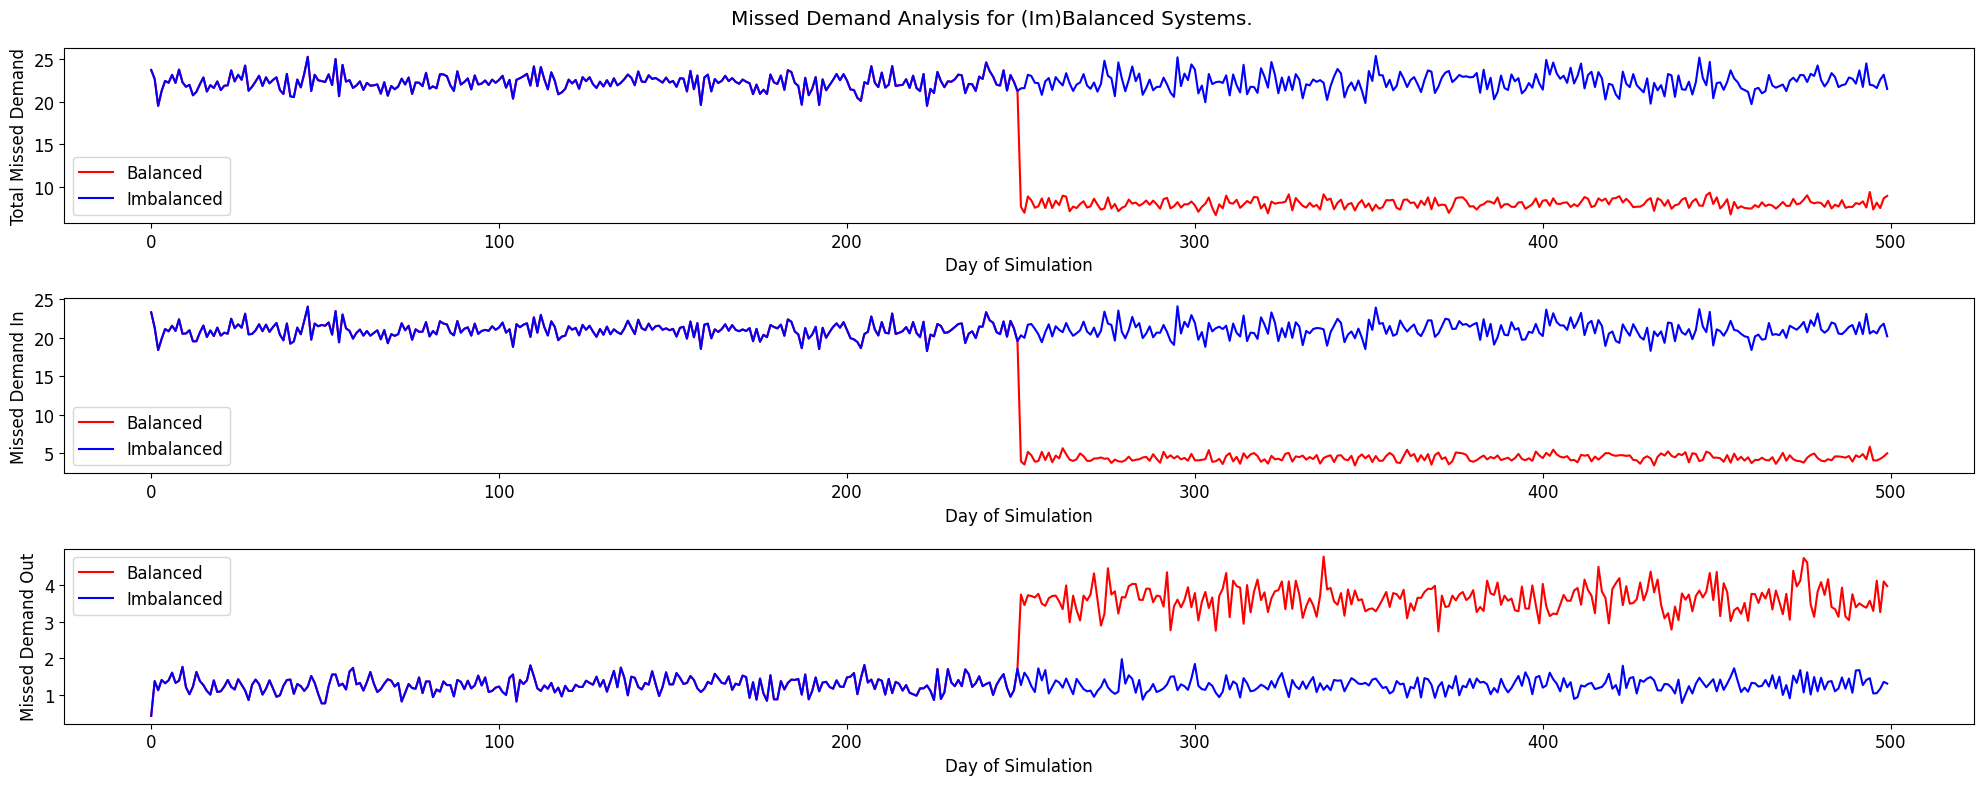

In [ ]:
num_replications = 100
length_of_simulation = 500
as_is_length = 250
# Record cumulative statistics
cumulative_statistics = dict()
for rep in range(1, num_replications + 1):
    cumulative_statistics[f'Replication {rep}'] = dict()
    for system in ['Imbalanced', 'Balanced']:
        cumulative_statistics[f'Replication {rep}'][system] = dict()
        # Fixed seed between systems in a single replication but different across replications
        random.seed(2025 + rep)
        np.random.seed(2025 + rep)
        # Run simulation
        if system == 'Imbalanced':
            data = simulation(length_of_simulation, length_of_simulation + 1)
        else:
            data = simulation(length_of_simulation, as_is_length)
        # Record cumulative stats
        cumulative_statistics[f'Replication {rep}'][system]['Served In'] = \
            sum(np.sum(data['Matrix']['Station ' + str(i)]['In'], axis=1) for i in range(1, num_stations + 1))
        cumulative_statistics[f'Replication {rep}'][system]['Served Out'] = \
            sum(np.sum(data['Matrix']['Station ' + str(i)]['Out'], axis=1) for i in range(1, num_stations + 1))
        cumulative_statistics[f'Replication {rep}'][system]['Total Served'] = \
            cumulative_statistics[f'Replication {rep}'][system]['Served In'] + \
            cumulative_statistics[f'Replication {rep}'][system]['Served Out']
        cumulative_statistics[f'Replication {rep}'][system]['Missed In'] = \
            sum(np.sum(data['Matrix']['Station ' + str(i)]['Missed In'], axis=1) for i in range(1, num_stations + 1))
        cumulative_statistics[f'Replication {rep}'][system]['Missed Out'] = \
            sum(np.sum(data['Matrix']['Station ' + str(i)]['Missed Out'], axis=1) for i in range(1, num_stations + 1))
        cumulative_statistics[f'Replication {rep}'][system]['Total Missed'] = \
            cumulative_statistics[f'Replication {rep}'][system]['Missed In'] + \
            cumulative_statistics[f'Replication {rep}'][system]['Missed Out']

# Average across replications
avg_cum_stat = dict()
for system in ['Imbalanced', 'Balanced']:
    avg_cum_stat[system] = dict()
    for stat in ['Served In', 'Served Out', 'Total Served', 'Missed In', 'Missed Out', 'Total Missed']:
        avg_cum_stat[system][stat] = sum(
            cumulative_statistics[f'Replication {rep}'][system][stat] for rep in range(1, num_replications + 1)
        ) / num_replications



mpl.rc('font', family='Times New Roman')
mpl.rc('font', size=12)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(20, 8))

ax[2].plot(avg_cum_stat['Balanced']['Missed Out'], color='red', label='Balanced')
ax[2].plot(avg_cum_stat['Imbalanced']['Missed Out'], color='blue', label='Imbalanced')
ax[2].legend()
ax[2].set_xlabel('Day of Simulation')
ax[2].set_ylabel('Missed Demand Out')


ax[1].plot(avg_cum_stat['Balanced']['Missed In'], color='red', label='Balanced')
ax[1].plot(avg_cum_stat['Imbalanced']['Missed In'], color='blue', label='Imbalanced')
ax[1].legend()
ax[1].set_xlabel('Day of Simulation')
ax[1].set_ylabel('Missed Demand In')


ax[0].plot(avg_cum_stat['Balanced']['Total Missed'], color='red', label='Balanced')
ax[0].plot(avg_cum_stat['Imbalanced']['Total Missed'], color='blue', label='Imbalanced')
ax[0].legend()
ax[0].set_xlabel('Day of Simulation')
ax[0].set_ylabel('Total Missed Demand')

fig.suptitle(f'Missed Demand Analysis for (Im)Balanced Systems.')

fig.tight_layout()
fig.show()